## AND-103 Task 5: Feature Engineering Pipeline

Builds `data/feature_matrix.csv` from three source datasets.

**Leakage constraint:** for any inspection row with date D, every feature value must be derived
exclusively from inspections and orders dated strictly *before* D. The current inspection's
outcome, type, and associated orders are all excluded from its own feature row.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

## AND-103 Task 5: Step 1 — Data Loading

Load all three source files. Parse every date column as datetime so downstream
date arithmetic works without manual conversion.

In [2]:
insp = pd.read_csv(
    '../data/inspection.csv',
    parse_dates=['Latest_INSPECTION_Date', 'Earliest_INSPECTION_Date'],
)
print(f"inspection.csv  → {insp.shape[0]:,} rows × {insp.shape[1]} cols")
print(f"Columns: {list(insp.columns)}")
print(f"Date range: {insp['Latest_INSPECTION_Date'].min().date()} → "
      f"{insp['Latest_INSPECTION_Date'].max().date()}")

inspection.csv  → 143,181 rows × 9 cols
Columns: ['originatingservicerequestnumber', 'InspectionCustomer', 'ElevatingDevicesNumber', 'InspectionNumber', 'InspectionLocation', 'InspectionType', 'Earliest_INSPECTION_Date', 'Latest_INSPECTION_Date', 'InspectionOutcome']
Date range: 2011-01-04 → 2017-01-09


In [3]:
orders = pd.read_csv(
    '../data/order.csv',
    parse_dates=['DateofIssue', 'ComplianceDate'],
)
print(f"order.csv       → {orders.shape[0]:,} rows × {orders.shape[1]} cols")
print(f"Columns: {list(orders.columns)}")

order.csv       → 162,172 rows × 15 cols
Columns: ['ElevatingDevicesNumber', 'TSSAStandardOrderNumber', 'RegulationReference', 'ClauseNumber', 'ClauseText', 'DIRECTIVE', 'Inspectionsadditionalinformation', 'RISKSCORE', 'Inspection_type', 'DateofIssue', 'StatusofInspectionOrder', 'inspectionnumber', 'DaystoComply', 'ComplianceDate', 'customerorderedtocomply']


In [4]:
merged = pd.read_csv('../data/merged_elevator_data.csv')
print(f"merged_elevator_data.csv → {merged.shape[0]:,} rows × {merged.shape[1]} cols")
print(f"Columns: {list(merged.columns)}")

merged_elevator_data.csv → 43,251 rows × 25 cols
Columns: ['ElevatingDevicesNumber', 'LocationoftheElevatingDevice', 'ElevatingDevicesLicenseNumber', 'LICENSESTATUS', 'LICENSEEXPIRYDATE', 'LICENSEHOLDER', 'LICENSEHOLDERACCOUNTNUMBER', 'LICENSEHOLDERADDRESS', 'BILLINGCUSTOMER', 'BILLINGADDRESS', 'BILLINGACCOUNT', 'Owner Name', 'Owner Address', 'Owner Account Number', 'Device Class', 'Device Type', 'DeviceStatus', 'Location of Device', 'under review', 'alteration_count', 'latest_alteration_type', 'latest_alteration_status', 'InspectionType', 'Latest_INSPECTION_Date', 'InspectionOutcome']


## AND-103 Task 5: Step 2 — Outcome Cleaning

### Before: raw distribution

In [5]:
raw_dist = insp['InspectionOutcome'].value_counts()
print(f"Raw InspectionOutcome distribution ({raw_dist.nunique()} unique values):")
print(raw_dist.to_string())

Raw InspectionOutcome distribution (30 unique values):
InspectionOutcome
Follow up                54605
Passed                   26064
DC Follow up             22302
All Orders Resolved      19555
Complete                  7506
Shutdown                  6110
Follow up Major           1117
Follow up Sub Major       1002
Follow Up Initial          877
Unable to Inspect          689
Fail Initial               602
Passed Major               551
Incomplete                 363
Vol Shut Down              346
Follow up Sub              286
Passed Sub                 215
DC Follow up Intial        200
MCP DC Follow up           185
Fail Sub                   154
Extend Time to Comply      121
MCP Follow up              102
Undergoing Major Alt        60
Complete Enforcement        51
DC Follow up Sub            46
Not Required                39
Cancelled                   13
Dismantled                   8
Inspection Complete          3
RC Established               3
Closed by Program           

### Grouping decision: 500-observation threshold

The raw distribution has 33 distinct outcome values, but 21 of them have fewer than 500
observations — collectively just **2,201 rows** out of 143,181 (1.5 %).

A class with under 500 examples is too sparse for a classifier to learn a reliable decision
boundary. Keeping every micro-category would balloon the target variable cardinality,
overfit to rare labels, and complicate evaluation. Grouping them into **Other** trades away
a tiny amount of label precision for a much more learnable, balanced target.

The twelve classes that survive (≥ 500 rows each):

| Class | Count |
|---|---|
| Follow up | 54,605 |
| Passed | 26,064 |
| DC Follow up | 22,302 |
| All Orders Resolved | 19,555 |
| Complete | 7,506 |
| Shutdown | 6,110 |
| Follow up Major | 1,117 |
| Follow up Sub Major | 1,002 |
| Follow Up Initial | 877 |
| Unable to Inspect | 689 |
| Fail Initial | 602 |
| Passed Major | 551 |

Everything else → **Other** (2,201 rows, 1.5 %).

In [6]:
OUTCOME_THRESHOLD = 500
keep_classes = set(raw_dist[raw_dist >= OUTCOME_THRESHOLD].index)

insp['outcome_class'] = insp['InspectionOutcome'].apply(
    lambda x: x if x in keep_classes else 'Other'
)

print("After cleaning:")
print(insp['outcome_class'].value_counts().to_string())
print(f"\nTotal classes: {insp['outcome_class'].nunique()}")

After cleaning:
outcome_class
Follow up              54605
Passed                 26064
DC Follow up           22302
All Orders Resolved    19555
Complete                7506
Shutdown                6110
Other                   2201
Follow up Major         1117
Follow up Sub Major     1002
Follow Up Initial        877
Unable to Inspect        689
Fail Initial             602
Passed Major             551

Total classes: 13


## AND-103 Task 5: Step 3 — Inspection Type Cleaning

### Raw distribution (after normalising whitespace)

In [7]:
# Normalise whitespace first — 'ED-Sub  Inspection' (double space) is a data entry error
insp['InspectionType_clean'] = (
    insp['InspectionType'].str.replace(r'\s+', ' ', regex=True).str.strip()
)
raw_types = insp['InspectionType_clean'].value_counts()
print(f"InspectionType distribution ({raw_types.nunique()} unique values after whitespace fix):")
print(raw_types.to_string())

InspectionType distribution (22 unique values after whitespace fix):
InspectionType_clean
ED-Followup Inspection            55730
ED-Periodic Inspection            44373
ED-Minor A Inspection              8222
ED-Followup Minor Alt              6659
ED-Sub Inspection                  6600
ED-Initial Inspection              5505
ED-Minor B Inspection              5077
ED-Sub Inspection Major            2985
ED-Unscheduled Inspection          2870
ED-Major Alteration Inspection     2421
ED-Followup Ownership Change        773
ED-Sub Failed Initial               704
ED-MCP Follow up                    433
ED-FU Enforcement Action Insp       255
ED-Enforcement Action               232
ED-MCP Enforcement Insp             185
ED-Re-Activate Inspection            76
ED-Followup Lic Insp                 49
ED-Non-Mandated Insp ON               6
ED-Followup No-Lic Insp               6
ED-Inspection Temp Lic                6
ED-PWGSC Insp                         5
ED-Followup Reg Non-Compliance

### Cleaning decisions

**Whitespace fix:** `ED-Sub  Inspection` (double space) was a data-entry typo. Normalising
whitespace merges it back into `ED-Sub Inspection`, adding 631 rows to that category
(5,969 → 6,600).

**Threshold grouping:** 13 types have fewer than 200 observations each — totalling only 341
rows (0.2 % of the dataset). These are mostly administrative or pilot-programme categories
(e.g. `ED-PWGSC Insp`, `ED-Perform L1 Incident Insp`) that never appear consistently enough
for the model to learn from. They are collapsed into **Other**.

Why 200 rather than 500?
InspectionType has 29 values vs. InspectionOutcome's 33, and the tail is much thinner.
Using 500 would also swallow `ED-MCP Follow up` (433 rows) and the two enforcement types
(255 + 232 = 487), which are genuinely distinct inspection scenarios. 200 captures the
meaningful semantic split without discarding useful signal.

In [8]:
TYPE_THRESHOLD = 200
rare_types = set(raw_types[raw_types < TYPE_THRESHOLD].index)
insp['InspectionType_clean'] = insp['InspectionType_clean'].apply(
    lambda x: 'Other' if x in rare_types else x
)

print("InspectionType_clean after grouping:")
print(insp['InspectionType_clean'].value_counts().to_string())

InspectionType_clean after grouping:
InspectionType_clean
ED-Followup Inspection            55730
ED-Periodic Inspection            44373
ED-Minor A Inspection              8222
ED-Followup Minor Alt              6659
ED-Sub Inspection                  6600
ED-Initial Inspection              5505
ED-Minor B Inspection              5077
ED-Sub Inspection Major            2985
ED-Unscheduled Inspection          2870
ED-Major Alteration Inspection     2421
ED-Followup Ownership Change        773
ED-Sub Failed Initial               704
ED-MCP Follow up                    433
Other                               342
ED-FU Enforcement Action Insp       255
ED-Enforcement Action               232


## AND-103 Task 5: Step 4 — Prior Inspection Features

### Leakage boundary

**"Prior" means:** all inspection records for the same elevator (`ElevatingDevicesNumber`)
with `Latest_INSPECTION_Date` **strictly earlier than** the current row's date.

**Excluded from every row's features:**
- The current inspection itself (same date is excluded — `<` not `<=`)
- Any other inspection for the same elevator on the same date (same-day sibling rows
  are excluded; they would not be available before the day's first inspection occurs)
- All future inspections for this elevator

### Algorithm: daily aggregate + cumsum + shift(1)

A naive row-by-row filter would be O(n²) over 143 k rows.
The efficient approach:

1. Collapse each elevator × date to one summary row (daily aggregate).
2. Within each elevator, compute a running cumulative sum of each metric.
3. `shift(1)` moves the cumulative total one date back, so each date's row sees only
   the sum of *all prior dates* — the current date's contribution is never included.
   Multiple inspections on the same date are handled atomically: they share a single
   daily aggregate row and thus all inherit the same prior-date total.

### Rolling pass rate: expanding window

The inspection history per elevator is sparse (median ~3 records per elevator), so a
fixed window (e.g., last 5 inspections) would return NaN for the majority of rows.
An expanding window — pass-like outcomes / total prior inspections — uses all available
signal while remaining strictly prior-only.

**"Pass-like" definition:** outcomes that indicate no further corrective action is required:
`Passed`, `All Orders Resolved`, `Complete`, `Passed Major`. This mirrors the regulatory
intent of the Passed class from the original TSSA categories.

In [9]:
def sanitize(s):
    """Lowercase, non-alphanumeric → underscore, strip leading/trailing underscores."""
    return re.sub(r'[^a-z0-9]+', '_', s.lower()).strip('_')

outcome_classes = sorted(insp['outcome_class'].unique())
insp_types      = sorted(insp['InspectionType_clean'].unique())
PASS_LIKE = {'Passed', 'All Orders Resolved', 'Complete', 'Passed Major'}

print(f"Outcome classes ({len(outcome_classes)}): {outcome_classes}")
print(f"InspectionType classes ({len(insp_types)}): {insp_types}")

Outcome classes (13): ['All Orders Resolved', 'Complete', 'DC Follow up', 'Fail Initial', 'Follow Up Initial', 'Follow up', 'Follow up Major', 'Follow up Sub Major', 'Other', 'Passed', 'Passed Major', 'Shutdown', 'Unable to Inspect']
InspectionType classes (16): ['ED-Enforcement Action', 'ED-FU Enforcement Action Insp', 'ED-Followup Inspection', 'ED-Followup Minor Alt', 'ED-Followup Ownership Change', 'ED-Initial Inspection', 'ED-MCP Follow up', 'ED-Major Alteration Inspection', 'ED-Minor A Inspection', 'ED-Minor B Inspection', 'ED-Periodic Inspection', 'ED-Sub Failed Initial', 'ED-Sub Inspection', 'ED-Sub Inspection Major', 'ED-Unscheduled Inspection', 'Other']


In [10]:
# Create binary indicator columns — used inside groupby aggregation
for cls in outcome_classes:
    insp[f'_oc_{sanitize(cls)}'] = (insp['outcome_class'] == cls).astype(int)
for typ in insp_types:
    insp[f'_it_{sanitize(typ)}'] = (insp['InspectionType_clean'] == typ).astype(int)
insp['_is_pass_like'] = insp['outcome_class'].isin(PASS_LIKE).astype(int)

In [11]:
# Build the aggregation spec dynamically
agg_dict = {
    'day_total':        ('InspectionNumber', 'count'),
    'day_last_outcome': ('outcome_class', 'last'),
    'day_pass_like':    ('_is_pass_like', 'sum'),
}
for cls in outcome_classes:
    agg_dict[f'day_oc_{sanitize(cls)}'] = (f'_oc_{sanitize(cls)}', 'sum')
for typ in insp_types:
    agg_dict[f'day_it_{sanitize(typ)}'] = (f'_it_{sanitize(typ)}', 'sum')

daily = (
    insp
    .groupby(['ElevatingDevicesNumber', 'Latest_INSPECTION_Date'])
    .agg(**agg_dict)
    .reset_index()
    .sort_values(['ElevatingDevicesNumber', 'Latest_INSPECTION_Date'])
)
print(f"Daily aggregate rows: {len(daily):,}  "
      f"(vs {len(insp):,} inspection rows — ratio: "
      f"{len(insp)/len(daily):.2f} inspections per elevator-day)")

Daily aggregate rows: 132,212  (vs 143,181 inspection rows — ratio: 1.08 inspections per elevator-day)


In [12]:
# cumsum + shift(1) → 'prior' prefix
shift_cols = (
    ['day_total', 'day_pass_like']
    + [f'day_oc_{sanitize(c)}' for c in outcome_classes]
    + [f'day_it_{sanitize(t)}' for t in insp_types]
)
for dcol in shift_cols:
    pcol = dcol.replace('day_', 'prior_', 1)
    daily[pcol] = (
        daily.groupby('ElevatingDevicesNumber')[dcol]
             .transform(lambda x: x.cumsum().shift(1))
    )

# Rename for clarity
daily['prior_inspection_count'] = daily['prior_total']

# Days since last inspection (NaN on first inspection — intentionally not filled)
daily['prev_date'] = (
    daily.groupby('ElevatingDevicesNumber')['Latest_INSPECTION_Date'].shift(1)
)
daily['days_since_last_inspection'] = (
    daily['Latest_INSPECTION_Date'] - daily['prev_date']
).dt.days

# Most recent prior outcome class (NaN on first inspection)
daily['most_recent_prior_outcome'] = (
    daily.groupby('ElevatingDevicesNumber')['day_last_outcome'].shift(1)
)

# Rolling pass rate: expanding pass-like / total
daily['rolling_pass_rate'] = daily['prior_pass_like'] / daily['prior_total']

In [13]:
# Merge daily-level features back to individual inspection rows (many-to-one)
daily_feature_cols = (
    ['ElevatingDevicesNumber', 'Latest_INSPECTION_Date',
     'prior_inspection_count', 'days_since_last_inspection',
     'most_recent_prior_outcome', 'rolling_pass_rate']
    + [f'prior_oc_{sanitize(c)}' for c in outcome_classes]
    + [f'prior_it_{sanitize(t)}' for t in insp_types]
)
before = len(insp)
insp = insp.merge(
    daily[daily_feature_cols],
    on=['ElevatingDevicesNumber', 'Latest_INSPECTION_Date'],
    how='left',
)
print(f"Rows before merge: {before:,}  |  after: {len(insp):,}")

# Sanity check against manually verified values
r = insp[
    (insp['ElevatingDevicesNumber'] == 17489)
    & (insp['Latest_INSPECTION_Date'] == '2014-02-12')
].iloc[0]
print(f"\nSanity check — elevator 17489 @ 2014-02-12 (manually verified against raw CSV):")
print(f"  prior_inspection_count = {r['prior_inspection_count']}  (expected 9)")
print(f"  prior_oc_shutdown      = {r['prior_oc_shutdown']}  (expected 4)")
print(f"  prior_oc_follow_up     = {r['prior_oc_follow_up']}  (expected 3)")
print(f"  prior_oc_passed        = {r['prior_oc_passed']}  (expected 1)")
print(f"  prior_oc_all_orders_resolved = {r['prior_oc_all_orders_resolved']}  (expected 1)")

Rows before merge: 143,181  |  after: 143,181

Sanity check — elevator 17489 @ 2014-02-12 (manually verified against raw CSV):
  prior_inspection_count = 9.0  (expected 9)
  prior_oc_shutdown      = 4.0  (expected 4)
  prior_oc_follow_up     = 3.0  (expected 3)
  prior_oc_passed        = 1.0  (expected 1)
  prior_oc_all_orders_resolved = 1.0  (expected 1)


## AND-103 Task 5: Step 5 — Prior Order Features

The spec's correct aggregation order is:
1. Identify prior inspections (date < D) for this elevator.
2. Collect those inspection numbers.
3. Select orders whose `inspectionnumber` is in that set.
4. Aggregate.

Using the daily cumsum + shift pattern preserves this order: orders are tagged with their
inspection's date via an `inspectionnumber` join, aggregated per (elevator, date), then
shifted — so only orders linked to inspections *before* D appear.

In [14]:
# Drop free-text / regulatory columns that are out of scope per spec
DROP_COLS = [
    'DIRECTIVE', 'ClauseText', 'RegulationReference', 'ClauseNumber',
    'TSSAStandardOrderNumber', 'Inspectionsadditionalinformation',
]
orders = orders.drop(columns=DROP_COLS, errors='ignore')
print(f"order.csv retained columns: {list(orders.columns)}")

order.csv retained columns: ['ElevatingDevicesNumber', 'RISKSCORE', 'Inspection_type', 'DateofIssue', 'StatusofInspectionOrder', 'inspectionnumber', 'DaystoComply', 'ComplianceDate', 'customerorderedtocomply']


### RISKSCORE: missing value analysis and imputation decision

RISKSCORE nulls: 41,553 of 162,172 (25.6%)

count    120619.000000
mean         11.520786
std         190.868164
min           0.000000
25%           0.000015
50%          15.000000
75%          15.000000
max       20316.561950
Name: RISKSCORE, dtype: float64


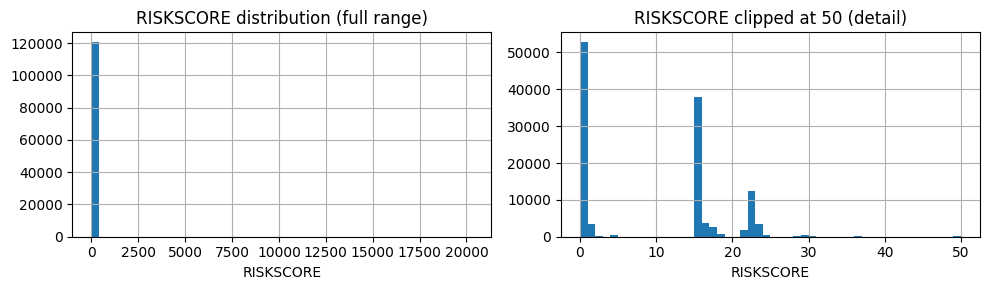

In [15]:
null_count = orders['RISKSCORE'].isna().sum()
print(f"RISKSCORE nulls: {null_count:,} of {len(orders):,} ({null_count/len(orders)*100:.1f}%)")
print()
print(orders['RISKSCORE'].describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
orders['RISKSCORE'].dropna().hist(bins=50, ax=axes[0])
axes[0].set_title('RISKSCORE distribution (full range)')
axes[0].set_xlabel('RISKSCORE')
orders['RISKSCORE'].clip(upper=50).dropna().hist(bins=50, ax=axes[1])
axes[1].set_title('RISKSCORE clipped at 50 (detail)')
axes[1].set_xlabel('RISKSCORE')
plt.tight_layout()
plt.show()

### Imputation decision

**25.6 % of RISKSCORE values are missing.**

Distribution characteristics:
- Heavily right-skewed: median 15, mean ~11.5, max > 20,000.
- The extreme outliers (> 100) inflate the mean substantially.

**Decision: median imputation (global median = 15.0).**

Justification:
1. The mean is not representative because of the extreme right tail.
2. 15.0 is the most common non-null value, making it the least wrong fill.
3. Missing values appear across many elevators and inspection dates without a clear
   systematic pattern; there is no evidence that nulls indicate a specific risk level
   that should be treated differently.
4. An alternative (exclude nulls from the mean per day) would undercount the denominator
   for the cumulative mean, distorting the time-series aggregation.

In [16]:
global_median_risk = orders['RISKSCORE'].median()
print(f"Global RISKSCORE median: {global_median_risk}")
orders['RISKSCORE_imputed'] = orders['RISKSCORE'].fillna(global_median_risk)

Global RISKSCORE median: 15.0


In [17]:
# Tag each order with its inspection's date (to enforce the prior-only boundary)
date_map = insp[['InspectionNumber', 'Latest_INSPECTION_Date']].drop_duplicates()
orders_dated = orders.merge(
    date_map, left_on='inspectionnumber', right_on='InspectionNumber', how='left'
)
unmatched = orders_dated['Latest_INSPECTION_Date'].isna().sum()
print(f"Orders matched to an inspection date: {orders_dated['Latest_INSPECTION_Date'].notna().sum():,}")
print(f"Orders without a matching inspection (excluded): {unmatched:,}")
orders_dated = orders_dated.dropna(subset=['Latest_INSPECTION_Date'])

Orders matched to an inspection date: 162,172
Orders without a matching inspection (excluded): 0


In [18]:
# Daily order aggregates per (elevator, inspection_date)
daily_orders = (
    orders_dated
    .groupby(['ElevatingDevicesNumber', 'Latest_INSPECTION_Date'])
    .agg(
        day_order_count = ('inspectionnumber', 'count'),
        day_risk_sum    = ('RISKSCORE_imputed', 'sum'),
    )
    .reset_index()
    .sort_values(['ElevatingDevicesNumber', 'Latest_INSPECTION_Date'])
)

# Cumulative order count (prior dates only)
daily_orders['prior_order_count'] = (
    daily_orders.groupby('ElevatingDevicesNumber')['day_order_count']
                .transform(lambda x: x.cumsum().shift(1))
                .fillna(0).astype(int)
)

# Cumulative risk sum, divided by prior order count → proper weighted mean
# (avoids distortion from averaging per-day means when days have unequal counts)
daily_orders['prior_risk_sum'] = (
    daily_orders.groupby('ElevatingDevicesNumber')['day_risk_sum']
                .transform(lambda x: x.cumsum().shift(1))
)
daily_orders['prior_mean_riskscore'] = (
    daily_orders['prior_risk_sum'] / daily_orders['prior_order_count']
)

In [19]:
# Merge order features back onto the inspection rows
order_feature_cols = [
    'ElevatingDevicesNumber', 'Latest_INSPECTION_Date',
    'prior_order_count', 'prior_mean_riskscore',
]
before = len(insp)
insp = insp.merge(
    daily_orders[order_feature_cols],
    on=['ElevatingDevicesNumber', 'Latest_INSPECTION_Date'],
    how='left',
)
insp['prior_order_count'] = insp['prior_order_count'].fillna(0).astype(int)
print(f"Rows before merge: {before:,}  |  after: {len(insp):,}")

# Sanity check (test_features.py Test 3)
r = insp[
    (insp['ElevatingDevicesNumber'] == 17489)
    & (insp['Latest_INSPECTION_Date'] == '2014-02-12')
].iloc[0]
print(f"\nSanity check — elevator 17489 @ 2014-02-12:")
print(f"  prior_order_count = {r['prior_order_count']}  (expected 15)")

Rows before merge: 143,181  |  after: 143,181

Sanity check — elevator 17489 @ 2014-02-12:
  prior_order_count = 15  (expected 15)


## AND-103 Task 5: Step 6 — Static Features

`merged_elevator_data.csv` contains one row per elevator with equipment type,
location, and alteration count. These features do not vary over time and
carry no leakage risk regardless of the inspection date.

In [20]:
# Extract city from the full address string.
# Addresses have the format: STREET  CITY  POSTAL_CODE  ON CA
# The city appears immediately before the postal code (letter-digit-letter digit-letter-digit).

SKIP_WORDS = {
    'N','S','E','W','NE','NW','SE','SW',
    'ST','AVE','DR','RD','BLVD','CRT','CT','PL','LN',
    'CIR','HWY','WAY','PKWY','PKY','CRES','BLDG','OF',
}
TWO_WORD_CITIES = {
    'NORTH YORK','NIAGARA FALLS','THUNDER BAY','ST CATHARINES',
    'LITTLE CURRENT','OWEN SOUND','NORTH BAY','RICHMOND HILL','ELLIOT LAKE',
}

def extract_city(addr):
    addr = str(addr).strip()
    m = re.search(r'([A-Z]\d[A-Z]\s+\d[A-Z]\d)', addr)
    if not m:
        return 'Unknown'
    before = addr[:m.start()].strip().split()
    while before and (before[-1] in SKIP_WORDS or before[-1].isdigit()):
        before.pop()
    if not before:
        return 'Unknown'
    candidate2 = ' '.join(before[-2:]) if len(before) >= 2 else ''
    if candidate2 in TWO_WORD_CITIES:
        return candidate2
    return before[-1]

merged['City'] = merged['LocationoftheElevatingDevice'].apply(extract_city)

city_counts = merged['City'].value_counts()
CITY_MIN = 200
merged['City'] = merged['City'].apply(
    lambda c: c if city_counts.get(c, 0) >= CITY_MIN else 'Other'
)
print(f"City distribution after grouping rare cities (< {CITY_MIN} elevators → Other):")
print(merged['City'].value_counts().to_string())

City distribution after grouping rare cities (< 200 elevators → Other):
City
TORONTO          12178
Other             6732
OTTAWA            3460
MISSISSAUGA       2312
LONDON            1626
SCARBOROUGH       1527
HAMILTON          1438
ETOBICOKE         1193
NORTH YORK         956
WINDSOR            783
BRAMPTON           781
MARKHAM            667
KITCHENER          663
KINGSTON           617
WATERLOO           565
BURLINGTON         563
OAKVILLE           537
WILLOWDALE         535
GUELPH             471
OSHAWA             444
RICHMOND HILL      420
ST CATHARINES      413
THUNDER BAY        391
NIAGARA FALLS      391
MILLS              371
SUDBURY            369
BARRIE             333
DOWNSVIEW          310
PETERBOROUGH       305
THORNHILL          299
NEPEAN             255
BRANTFORD          246
VAUGHAN            246
CAMBRIDGE          244
MARIE              208
SARNIA             202
KANATA             200


In [21]:
static = merged[['ElevatingDevicesNumber', 'Device Type', 'City', 'alteration_count']].copy()

before = len(insp)
insp = insp.merge(static, on='ElevatingDevicesNumber', how='left')
after = len(insp)
unmatched = insp['Device Type'].isna().sum()

if unmatched > 0:
    print(f"WARNING: {unmatched:,} inspection rows did not match any elevator in "
          f"merged_elevator_data.csv — static features will be NaN for those rows.")
else:
    print("All inspection rows matched successfully.")

# Rename to the canonical column names required by the deliverable checklist
insp = insp.rename(columns={
    'Device Type':     'EquipmentType',
    'City':            'Location',
    'alteration_count': 'AlterationCount',
})

print(f"Rows before join: {before:,}  |  after: {after:,}")

Rows before join: 143,181  |  after: 143,181


## AND-103 Task 5: Step 7 — Encoding

### Which columns to encode and how

**Dummy encoding (one-hot)** is appropriate for nominal categoricals with low-to-moderate
cardinality where no ordinal relationship exists between categories.

**Label encoding** is appropriate for ordinal categoricals, or when cardinality is so high
(> ~50 values) that dummy encoding would produce an excessive number of columns.

Columns to encode:

| Column | Cardinality | Method | Reason |
|---|---|---|---|
| `Device Type` | 5 | Dummy | Nominal; no ordering; 4 extra columns is negligible |
| `City` | ~35 + Other | Dummy | Nominal geographic categories; ~35 columns manageable |
| `most_recent_prior_outcome` | 13 + NaN | Dummy + `dummy_na=True` | Nominal; NaN means first inspection — needs its own indicator |

**Not encoded:**
- `InspectionType_clean` of the *current* row — this is a leakage source (the inspection
  type cannot be known before the inspection occurs). The model will never see it.
  Prior inspection-type history is already captured as numeric `prior_it_*` count features.
- `outcome_class` (the target variable) — kept as string labels for the ML pipeline to handle.
- `ElevatingDevicesNumber` and `InspectionDate` — identifier columns, not features.

In [ ]:
before_cols = insp.shape[1]

# Encode EquipmentType and Location from copies so the original named columns
# are preserved in the saved feature matrix (required by deliverable checklist).
for col, prefix in [('EquipmentType', 'EquipmentType'), ('Location', 'Location')]:
    dummies = pd.get_dummies(insp[col], prefix=prefix, dummy_na=True)
    insp = pd.concat([insp, dummies], axis=1)

# most_recent_prior_outcome has no stand-alone value as a raw string; encode normally
insp = pd.get_dummies(
    insp,
    columns=['most_recent_prior_outcome'],
    prefix=['prior_outcome'],
    dummy_na=True,
)

print(f"Columns before encoding: {before_cols}  |  after: {insp.shape[1]}")
new_dummy_cols = [c for c in insp.columns
                  if c.startswith(('EquipmentType_', 'Location_', 'prior_outcome_'))]
print(f"New dummy columns ({len(new_dummy_cols)}): {new_dummy_cols}")

## AND-103 Task 5: Step 8 — Missing Value Audit

In [23]:
nan_counts = insp.isna().sum()
nan_report = nan_counts[nan_counts > 0].sort_values(ascending=False)
print("Columns with remaining NaNs:")
print(nan_report.to_string() if len(nan_report) else "None")

Columns with remaining NaNs:
prior_mean_riskscore                       118957
AlterationCount                             53179
prior_inspection_count                      43324
prior_it_ed_fu_enforcement_action_insp      43324
days_since_last_inspection                  43324
rolling_pass_rate                           43324
prior_oc_all_orders_resolved                43324
prior_oc_fail_initial                       43324
prior_oc_follow_up_initial                  43324
prior_oc_complete                           43324
prior_oc_dc_follow_up                       43324
prior_oc_follow_up_sub_major                43324
prior_oc_other                              43324
prior_oc_passed                             43324
prior_oc_passed_major                       43324
prior_oc_shutdown                           43324
prior_oc_unable_to_inspect                  43324
prior_oc_follow_up                          43324
prior_oc_follow_up_major                    43324
prior_it_ed_minor_b_i

### Fill decisions per column

| Column | Fill strategy | Reasoning |
|---|---|---|
| `prior_inspection_count` and all `prior_oc_*`, `prior_it_*` | 0 | NaN = first inspection; no prior history means count is 0 |
| `rolling_pass_rate` | 0 | No prior inspections to compute a rate from |
| `days_since_last_inspection` | **Keep NaN** | 0 would falsely imply the elevator was inspected the same day. Tree-based models handle NaN natively; imputation strategy left to the ML pipeline (Task 6) |
| `prior_mean_riskscore` | Global median (15.0) | NaN when no prior orders exist — same imputation used within orders to stay consistent |
| `alteration_count` | 0 | NaN means no alteration records in the ETL output → 0 alterations |
| `prior_order_count` | Already filled to 0 in Step 5 | — |

In [24]:
# Columns whose NaN means 'no prior history' → fill with 0
fill_zero_cols = (
    ['prior_inspection_count', 'rolling_pass_rate']
    + [f'prior_oc_{sanitize(c)}' for c in outcome_classes]
    + [f'prior_it_{sanitize(t)}' for t in insp_types]
)
for col in fill_zero_cols:
    if col in insp.columns:
        insp[col] = insp[col].fillna(0)

# prior_mean_riskscore: fill with global median for rows with no prior orders
insp['prior_mean_riskscore'] = insp['prior_mean_riskscore'].fillna(global_median_risk)

# AlterationCount: fill NaN with 0
insp['AlterationCount'] = insp['AlterationCount'].fillna(0).astype(int)

# days_since_last_inspection: intentionally left as NaN
# (see reasoning in the markdown cell above)

nan_after = insp.isna().sum()
remaining = nan_after[nan_after > 0]
print("NaN counts after fill:")
print(remaining.to_string() if len(remaining) else "None (all handled)")
print()
print("Expected: only days_since_last_inspection should remain (by design).")

NaN counts after fill:
InspectionLocation              113
days_since_last_inspection    43324

Expected: only days_since_last_inspection should remain (by design).


## AND-103 Task 5: Step 9 — Save Feature Matrix

Identifier columns (`ElevatingDevicesNumber`, `InspectionDate`) are retained in the CSV
but are **not model features**. The ML pipeline (Task 6) uses `InspectionDate` for the
time-based train/test split and drops both identifiers before fitting.

Columns excluded from the saved matrix:
- `InspectionOutcome` (raw, replaced by `outcome_class`)
- `InspectionType` and `InspectionType_clean` (current row — leakage source)
- `Earliest_INSPECTION_Date` (not used in this pipeline)
- `InspectionNumber` (row-level identifier, not a model feature)
- `originatingservicerequestnumber`, `InspectionCustomer`, `InspectionLocation` (admin)
- All `_oc_*`, `_it_*`, `_is_pass_like` helper indicator columns

In [25]:
DROP_FROM_MATRIX = [
    'InspectionOutcome',
    'InspectionType',
    'InspectionType_clean',
    'Earliest_INSPECTION_Date',
    'InspectionNumber',
    'originatingservicerequestnumber',
    'InspectionCustomer',
    'InspectionLocation',
]
# Drop all private helper columns created during feature construction
helper_cols = [c for c in insp.columns if c.startswith('_')]

feature_matrix = insp.drop(
    columns=[c for c in DROP_FROM_MATRIX + helper_cols if c in insp.columns]
)

# Rename Latest_INSPECTION_Date → InspectionDate for clarity in downstream pipelines
feature_matrix = feature_matrix.rename(columns={'Latest_INSPECTION_Date': 'InspectionDate'})

feature_matrix.to_csv('../data/feature_matrix.csv', index=False)

print(f"Saved: {feature_matrix.shape[0]:,} rows × {feature_matrix.shape[1]} columns")
print(f"\nColumns ({feature_matrix.shape[1]}):")
print(list(feature_matrix.columns))
print(f"\nTarget variable distribution:")
print(feature_matrix['outcome_class'].value_counts().to_string())

Saved: 143,181 rows × 96 columns

Columns (96):
['ElevatingDevicesNumber', 'InspectionDate', 'outcome_class', 'prior_inspection_count', 'days_since_last_inspection', 'rolling_pass_rate', 'prior_oc_all_orders_resolved', 'prior_oc_complete', 'prior_oc_dc_follow_up', 'prior_oc_fail_initial', 'prior_oc_follow_up_initial', 'prior_oc_follow_up', 'prior_oc_follow_up_major', 'prior_oc_follow_up_sub_major', 'prior_oc_other', 'prior_oc_passed', 'prior_oc_passed_major', 'prior_oc_shutdown', 'prior_oc_unable_to_inspect', 'prior_it_ed_enforcement_action', 'prior_it_ed_fu_enforcement_action_insp', 'prior_it_ed_followup_inspection', 'prior_it_ed_followup_minor_alt', 'prior_it_ed_followup_ownership_change', 'prior_it_ed_initial_inspection', 'prior_it_ed_mcp_follow_up', 'prior_it_ed_major_alteration_inspection', 'prior_it_ed_minor_a_inspection', 'prior_it_ed_minor_b_inspection', 'prior_it_ed_periodic_inspection', 'prior_it_ed_sub_failed_initial', 'prior_it_ed_sub_inspection', 'prior_it_ed_sub_inspectio